In [94]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.datasets import fetch_openml
from sklearn.metrics import pairwise_distances
from sklearn import datasets
import math
import sklearn
import importlib
from scipy.spatial.distance import squareform
from tqdm import tqdm
import matplotlib.pyplot as plt
importlib.reload(sklearn.manifold._t_sne)

<module 'sklearn.manifold._t_sne' from '/insomnia001/depts/iicd/users/vj2308/scikit-learn/sklearn/manifold/_t_sne.py'>

In [3]:
print(TSNE.__mro__)

(<class 'sklearn.manifold._t_sne.TSNE'>, <class 'sklearn.base.ClassNamePrefixFeaturesOutMixin'>, <class 'sklearn.base.TransformerMixin'>, <class 'sklearn.utils._set_output._SetOutputMixin'>, <class 'sklearn.base.BaseEstimator'>, <class 'sklearn.utils._repr_html.base.ReprHTMLMixin'>, <class 'sklearn.utils._repr_html.base._HTMLDocumentationLinkMixin'>, <class 'sklearn.utils._metadata_requests._MetadataRequester'>, <class 'object'>)


In [99]:
x,y=fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
print(x.shape)
x_train=x[:1000]/255

(70000, 784)


In [4]:
tsne=TSNE(n_components=2,
          perplexity=15,
          random_state=42,
          method="exact")
feat=tsne.fit_transform(x_train)

here


In [57]:
tsne.P_
tsne.Q_
tsne.scales_

array([[  0.       , -39.01581  ,  26.452894 , ..., -37.451237 ,
          7.7146244, -27.989658 ],
       [ 39.01581  ,   0.       ,  65.468704 , ...,   1.5645714,
         46.73043  ,  11.02615  ],
       [-26.452894 , -65.468704 ,   0.       , ..., -63.90413  ,
        -18.73827  , -54.44255  ],
       ...,
       [ 37.451237 ,  -1.5645714,  63.90413  , ...,   0.       ,
         45.165863 ,   9.461578 ],
       [ -7.7146244, -46.73043  ,  18.73827  , ..., -45.165863 ,
          0.       , -35.704285 ],
       [ 27.989658 , -11.02615  ,  54.44255  , ...,  -9.461578 ,
         35.704285 ,   0.       ]], shape=(1000, 1000), dtype=float32)

In [2]:
digits=datasets.load_digits()
small_x=digits.data/255
small_x_train=small_x[:1000]

In [3]:
small_tsne=TSNE(n_components=2,
          perplexity=15,
          random_state=42,
          method="exact")
small_feat=small_tsne.fit_transform(small_x_train)

here


In [70]:
def calc_direct_2order(tsne, feat, idx):
    p=squareform(tsne.P_)  #n x n
    q=squareform(tsne.Q_)  #n x n
    v=p-q        #symmetric
    n=feat.shape[0]
    m=feat.shape[1]

    d=feat[idx]-feat   #n x m
    e=1+np.linalg.norm(d, axis=1)**2 #n x 1
    d_=np.identity(m)  #n x n
    e_=2*d             #n x m

    total_e=1+np.sum(feat[:,None,:]-feat[None,:,:]**2, axis=2)
    sq=0              #scalar
    for i in range(n):
        for j in range(i+1,n):
            sq+=1/total_e[i,j]
    sq*=2   #definitive
    sq_=np.zeros((1,m))  #definitive
    for i in range(n):
        sq_+=1/e[i]*d[i]
    sq_*=-4

    v_=np.zeros((n,m))
    for i in range(n):
        v_[i]=2/e[i]**2*sq*d[i] + 1/e[i]*sq_
    v_/=sq**2

    direct_2order=np.zeros((m,m))
    for i in range(n):
        direct_2order+=1/e[i]* (np.dot(v_[i].T,d[i]) + v[idx,i]*d_ - v[idx,i]/e[i]*np.dot(e_[i].T,d[i]))

    return direct_2order

In [109]:
def calc_cross2order_single(tsne, x_train, feat, idx, k):
    scales=tsne.scales_      ##this is 1/(2*sigma**2)
    d=feat[idx]-feat    ##y_i - y_j   #n x m
    e=1+np.linalg.norm(d, axis=1)**2  #n x 1
    n=feat.shape[0]
    m=feat.shape[1]

    x_sq_distances_tot=pairwise_distances(x_train, squared=True)
    x_sq_distances=x_sq_distances_tot[idx] #n x 1
    
    x_k=x_train[:,k]      #n x 1
    x_k_distances=np.abs(x_k[:, np.newaxis]-x_k)
    
    s_pi=0   #eq 21
    partial_s_pi=0  #eq23
    for l in range(n):
        if idx!=l:
            temp=math.exp(-x_sq_distances[l]/scales[idx])
            s_pi+=temp
            partial_s_pi-=x_k_distances[idx,l]*2*scales[idx]*temp

    cross_2order=np.zeros((1,m))
    for j in range(n):   #j 
        e_ij=e[j]
        d_ij=d[j]
        v_ij_=0

        p_ji=math.exp(-x_sq_distances[j]/scales[idx])/s_pi   #eq20
        partial_p_ji=-(x_k_distances[idx,j]*2*scales[idx] + partial_s_pi/s_pi)*p_ji  #eq22

        s_pj=0    #eq25
        for l in range(n):
            if j!=l:
                s_pj+=math.exp(-x_sq_distances_tot[j][l]/scales[j]) 
            
        temp=math.exp(-x_sq_distances[j]/scales[j])
        p_ij=temp/s_pj  #eq 24
        partial_s_pj=x_k_distances[j,idx]*2*scales[j]*temp    #eq27
        partial_p_ij=(x_k_distances[j,idx]*2*scales[j] + partial_s_pj/s_pj)*p_ij #eq26

        v_ij_=partial_p_ij + partial_p_ji

        cross_2order+=v_ij_/e[j]*d[j]
        
    cross_2order*=2/n
    return cross_2order

In [63]:
def cross_2order_total(tsne, x_train, feat, idx):
    #for equation 6
    low_dim=feat.shape[1]
    high_dim=x_train.shape[1]
    
    total=np.empty((low_dim,high_dim))
    for k in tqdm(range(high_dim)):
        cross=calc_cross2order_single(tsne, x_train, feat, idx, k)
        total[:,k]=cross

    return total

In [66]:
def grad_wtr_y(tsne, feat):
    ##equation 7
    p=squareform(tsne.P_)
    q=squareform(tsne.Q_)
    n=feat.shape[0]
    low_dim=feat.shape[1]

    grad=np.zeros((n,low_dim))
    for i in tqdm(range(n)):
        temp=0
        d=feat[i]-feat    
        e=1+np.linalg.norm(d, axis=1)**2
        for j in range(n):
            if i!=j:
                temp+=(p[i,j]-q[i,j])*d[j]/(e[j]) 
        temp*=4
        grad[i]=temp

    return grad

In [74]:
def grad_wtr_x(direct_2order, cross_2order_total):
    ##equation 6
    inv=np.linalg.inv(direct_2order)
    grad=-np.dot(inv, cross_2order_total)
    return grad

In [104]:
direct_2order=calc_direct_2order(small_tsne, small_feat, 0)

In [110]:
cross_2order_tot=cross_2order_total(small_tsne, small_x_train, small_feat, 0)

100%|██████████████████████████████████████████| 64/64 [00:17<00:00,  3.60it/s]


In [111]:
grad_x=grad_wtr_x(direct_2order, cross_2order_tot)

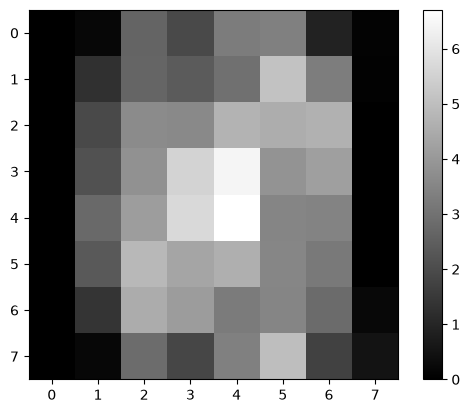

In [112]:
plt.imshow(grad_x[0,].reshape(8,8), cmap="gray")
plt.colorbar()
plt.show()

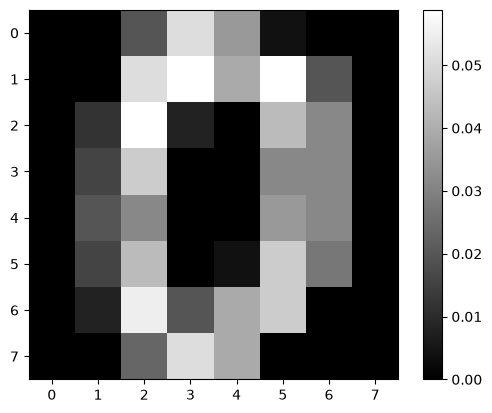

In [98]:
plt.imshow(small_x_train[0].reshape(8,8),cmap="gray")
plt.colorbar()
plt.show()

In [100]:
### real mnist dataset
tsne=TSNE(n_components=2,
          perplexity=15,
          random_state=42,
          method="exact")
feat=tsne.fit_transform(x_train)

here


In [101]:
idx=0

In [113]:
direct_2order=calc_direct_2order(tsne, feat, idx)

In [114]:
cross_2order_tot=cross_2order_total(tsne, x_train, feat, idx)

100%|████████████████████████████████████████| 784/784 [05:06<00:00,  2.55it/s]


In [124]:
grad_x=grad_wtr_x(direct_2order, cross_2order_tot)
nm_grad_x=grad_x/np.linalg.norm(grad_x)

Text(0.5, 1.0, 'og image')

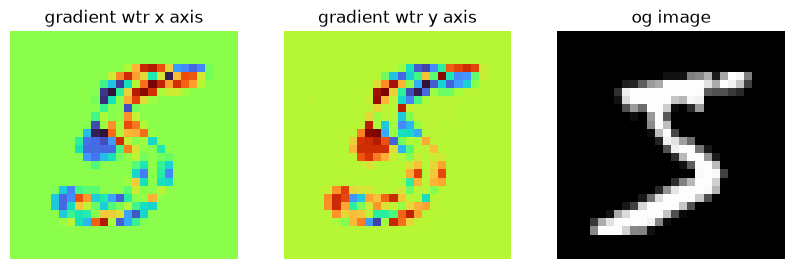

In [132]:
fig, ax=plt.subplots(1,3,figsize=(10,5))
ax[0].imshow(nm_grad_x[0].reshape(28,28),cmap="turbo")
ax[0].axis('off')
ax[0].set_title('gradient wtr x axis')

ax[1].imshow(nm_grad_x[1].reshape(28,28),cmap="turbo")
ax[1].axis('off')
ax[1].set_title('gradient wtr y axis')

ax[2].imshow(x_train[idx].reshape(28,28),cmap="gray")
ax[2].axis('off')
ax[2].set_title('og image')